<a href="https://colab.research.google.com/github/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP/blob/imasha/LSTM_negativelog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
sales = pd.read_csv('/content/drive/MyDrive/applied_deep_learning/sales_train_evaluation.csv')
calendar = pd.read_csv('/content/drive/MyDrive/applied_deep_learning/calendar.csv')
prices =pd.read_csv('/content/drive/MyDrive/applied_deep_learning/sell_prices.csv')

print(sales.shape)
sales.head()
#sales.describe()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


The sales_train_evaluation file has the sales data for each row with what category, department, store, state it falls into

There are three categories: Foods, Hobbies and Household. But within each catgeory there are multiple departments, for ecample: FOODS_1, FOODS_2, FOODS_3

In [4]:
sales["dept_id"].unique()

array(['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1',
       'FOODS_2', 'FOODS_3'], dtype=object)

Calender.csv tells us what each day in the sales data (d_1, d_2 etc) corresponds to in the real world (date, weekday, holidays)

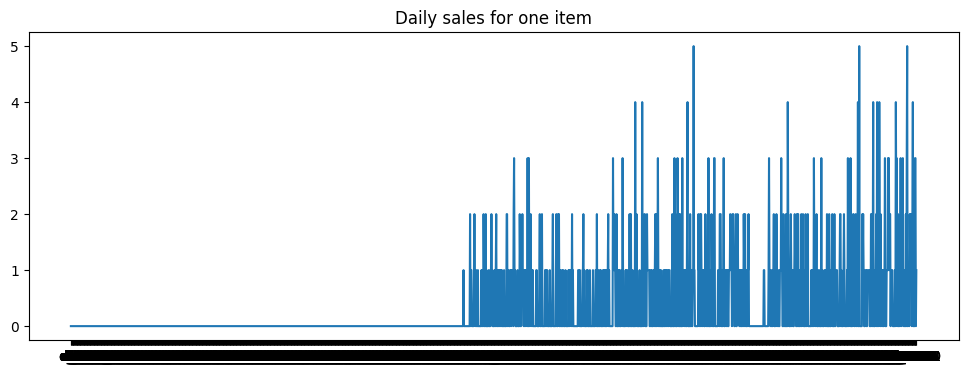

In [5]:
sample = sales.iloc[0, 6:]
sample = sample.astype(int)

plt.figure(figsize=(12,4))
plt.plot(sample)
plt.title("Daily sales for one item")
plt.show()
# how many units of the item were sold each day
# item was probably just introduced later

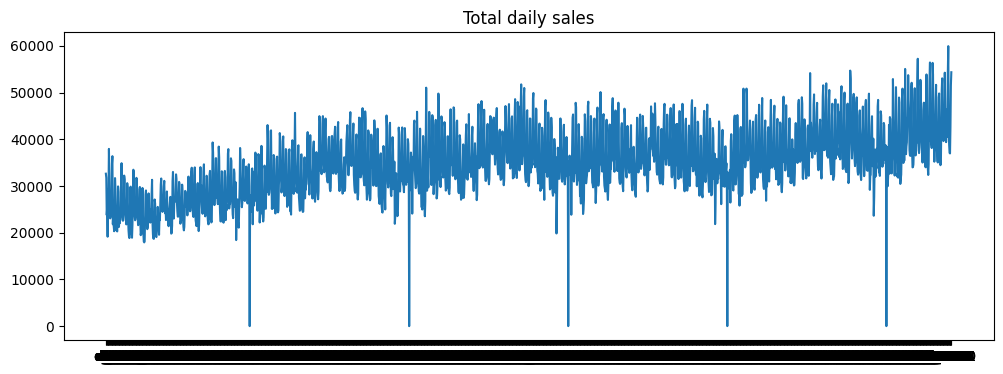

In [6]:
# total sales across all items
daily_sales = sales.iloc[:,6:].sum(axis=0)

plt.figure(figsize=(12,4))
plt.plot(daily_sales)
plt.title("Total daily sales")
plt.show()

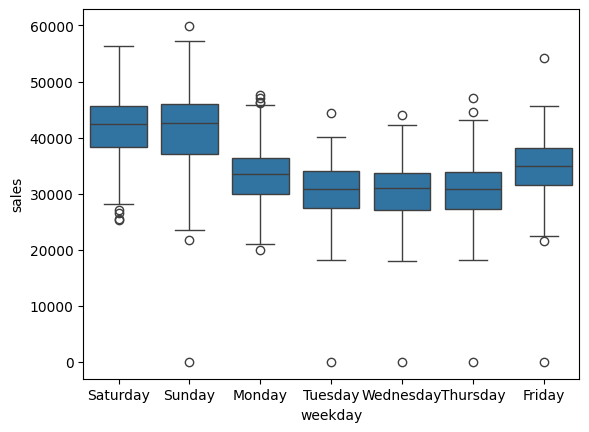

In [7]:
calendar_subset = calendar.iloc[:len(daily_sales)].copy()
calendar_subset['sales'] = daily_sales.values

sns.boxplot(x='weekday', y='sales', data=calendar_subset)
plt.show()
# shows us that weekend sales are generally higher than the weekdays

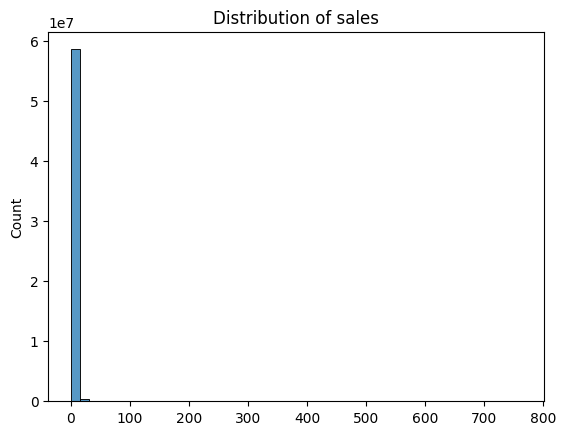

In [8]:
all_sales = sales.iloc[:,6:].values.flatten()

sns.histplot(all_sales, bins=50)
plt.title("Distribution of sales")
plt.show()

Large spike at 0 and a right skewed distribution

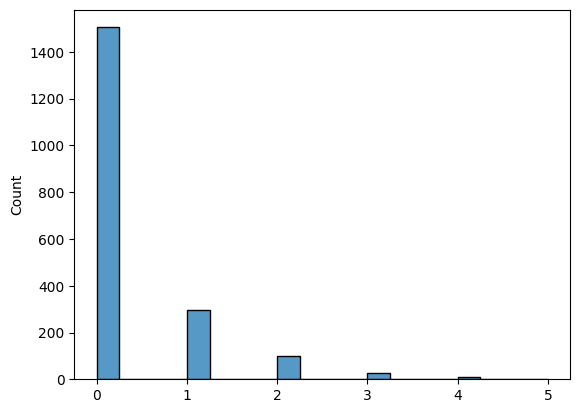

In [9]:
sample_sales = sales.iloc[0,6:].values
sample_sales = sample_sales.astype(int)
sns.histplot(sample_sales, bins=20)
plt.show()
# most items sales are 0

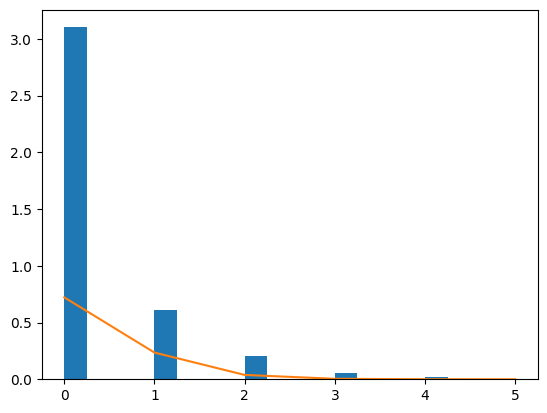

In [10]:
from scipy.stats import poisson

lambda_hat = np.mean(sample_sales)

x = np.arange(0, max(sample_sales)+1)
pmf = poisson.pmf(x, lambda_hat)

plt.hist(sample_sales, bins=20, density=True)
plt.plot(x, pmf)
plt.show()

Poisson won't work !

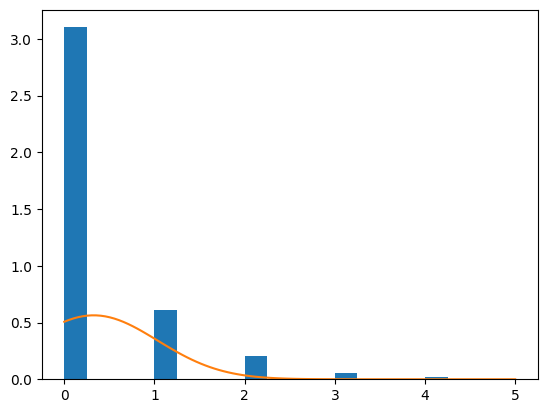

In [11]:
from scipy.stats import norm

mu, sigma = norm.fit(sample_sales)

x = np.linspace(min(sample_sales), max(sample_sales),100)

plt.hist(sample_sales, bins=20, density=True)
plt.plot(x, norm.pdf(x, mu, sigma))
plt.show()

Normal distribution will not work !

In [12]:
mean_sales = np.mean(sample_sales)
var_sales = np.var(sample_sales)

print(mean_sales, var_sales)

0.3261205564142195 0.5010642389437399


Poisson won't work as it assumes the variance is equal to the mean

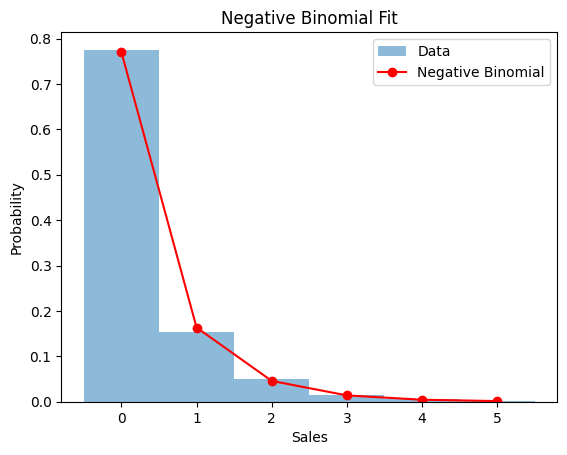

In [13]:
from scipy.stats import nbinom

mean = np.mean(sample_sales)
var = np.var(sample_sales)

p = mean / var
r = mean * p / (1 - p)

x = np.arange(0, max(sample_sales)+1)
pmf = nbinom.pmf(x, r, p)

# FIXED histogram
bins = np.arange(-0.5, max(sample_sales)+1.5, 1)

plt.hist(sample_sales, bins=bins, density=True, alpha=0.5, label="Data")
plt.plot(x, pmf, 'o-', color='red', label="Negative Binomial")

plt.legend()
plt.title("Negative Binomial Fit")
plt.xlabel("Sales")
plt.ylabel("Probability")
plt.show()

In [14]:
# keep the first 100 days of sakes
# first 6 columns are identifiers (id, item_id) then the remaining columns are daily sales (d_1, d_1)
# therefire becomes 6+100
sales_small = sales.iloc[:, :6+100]

# convert to long format as time-series work better with long format
# id_vars = columns to keep fixed
# var_name = 'd' column name for day labels so column d will have entries of d_1, d_2
# value_name = 'sales' column name for sales values
# melts the original dataset sales_small into a new datase
# original dataset structure : id -> item_id -> d_1 -> d_2 -> d_3 ....
# new dataset structure  id -> item_id -> d -> sales THATS IT
sales_long = pd.melt(
    sales_small,
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)
# only select the needed features from the calender dataset
# SNAP -> supplemental Nutrition Assistance Program, form of benefits
# snap_CA, snap_TX -> whether SNAP benefits are active in Calafornia, Texas etc
# 1 = SNAP benefits available that day
# 0 = not available
calendar_small = calendar[
    ['d','weekday','month','event_name_1','event_type_1','event_name_2', 'event_type_2','snap_CA','snap_TX','snap_WI','wm_yr_wk']
]
# Merge the sales data and calender data so that they join on d (day)
# how = 'left' -> keeps all sales rows
data = sales_long.merge(
    calendar_small,
    on='d',
    how='left'
)
# now we merge that dataset with the price data
# join on store_id, item_id etc
data = data.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)
# order the rows by store, item and then day
data = data.sort_values(['store_id','item_id','d'])
# some prices are not recorded every day
# group each store - item pair and fill the missing prices using the previous value
data['sell_price'] = data.groupby(
    ['store_id','item_id']
)['sell_price'].ffill()
# Price is defined per week, so this is safe, we can assume for that week it does not change
data['sell_price'] = data['sell_price'].bfill()
# show the data
print(data.head())
print(data.shape)


                                  id      item_id  dept_id cat_id store_id  \
1612     FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1   
276022   FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1   
3020122  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1   
306512   FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1   
337002   FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1   

        state_id      d  sales    weekday  month  event_name_1 event_type_1  \
1612          CA    d_1      3   Saturday      1           NaN          NaN   
276022        CA   d_10      0     Monday      2           NaN          NaN   
3020122       CA  d_100      0     Sunday      5  Mother's day     Cultural   
306512        CA   d_11      0    Tuesday      2           NaN          NaN   
337002        CA   d_12      0  Wednesday      2           NaN          NaN   

         snap_CA  snap_TX  snap_WI  wm_yr_wk  sell_price

We will use a LSTM (a type of RNN) which will have an output layer that predicts a probability distribution that it thinks EACH data point follows eg) sales ~ NB(μ=4.8, α=1.2), it then uses negative loss likelihood to give probabilities like:
P(y=0) = 0.60
P(y=1) = 0.25
P(y=2) = 0.10
P(y=5) = 0.01
And then predicts the label with the highest probability. So it describes all possible future outcomes + their likelihood

The loss function we use negative loss likelihood, which calculates the loss using:
loss = -log P(y_true | μ, α). For example, if the model predicts P(y=3) = 0.4, then -log(0.4) = 0.92, small loss thats acceptable. But if the model predicts P(y=3) = 0.01, -log(0.01) = 4.6 which is a large loss, therefore penalised more.

Full pipeline

Input sequence

      ↓
LSTM

      ↓
Hidden state h

      ↓
μ, α (distribution parameters)

      ↓
Negative Binomial distribution

      ↓
Compute P(true value)

      ↓
Loss = -log(probability)

      ↓
Update model



In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
class M5Dataset(Dataset):
    # takes in our new dataset data, a list of features
    # window=30 means how many past days to use
    def __init__(self, data, features, window=30):

        self.features = features
        self.window = window
        # time series for one item
        self.series = []
        # each item becomes its own time series, group by item_id
        grouped = data.groupby("item_id")
        # loop through each row for that item
        for _, df in grouped:
            # convert it into an numpy array
            values = df[features].values
            # only keep items with enough history (30 days worth of information)
            if len(values) > window:
                self.series.append(values)

    def __len__(self):
        # gets the length of the dataset, sum over all items of the windows
        # len(s) = 100, window = 30, that means 100-30 = 70 samples
        total = 0
        for s in self.series:
            total += len(s) - self.window

        return total

    def __getitem__(self, idx):
      # loop through the time series of each item
      # for example for item A you#ll have:
      # day , sales, price
      # d1 -> 5 -> 2.0
      # d2 -> 7 -> 2.0
      # d3 -> 6 -> 2.5
      # self.series = [array([[5,2.0],[7,2.0],[6,2.5]]),   # item A
      # array([[3,1.5],[4,1.5],[8,1.8]])   ] # item B
        for s in self.series:
          # so loop through each item's time series & check if the index belongs to the item
          # each series produces (len(s) - window) samples
            if idx < len(s) - self.window:
                x = s[idx:idx+self.window]
                y = int(s[idx+self.window, 0])
                return torch.tensor(x).float(), torch.tensor(y).float()
            idx -= (len(s) - self.window)

In [16]:
# create the LSTM
class ProbLSTM(nn.Module):

    def __init__(self, input_size, hidden_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_size, 1)
        self.fc_alpha = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        h = out[:, -1, :]

        mu = torch.nn.functional.softplus(self.fc_mu(h)) + 1e-6
        alpha = torch.clamp(torch.nn.functional.softplus(self.fc_alpha(h)),min=1e-4,max=10)
        return mu.squeeze(), alpha.squeeze()


In [17]:

def nll_loss(mu, alpha, y):

    var = mu + alpha * mu**2

    r = mu**2 / (var - mu + 1e-8)
    p = r / (r + mu)

    dist = torch.distributions.NegativeBinomial(
        total_count=r,
        probs=p
    )

    return -dist.log_prob(y).mean()

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader


numerical_features = [
    'sales',
    'sell_price',
    'month',
    'snap_CA',
    'snap_TX',
    'snap_WI',
    'lag1',
    'lag7',
    'lag28'
]

categorical_features = [
    'weekday',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id',
    'event_name_1'
]


# One-hot encode
data = pd.get_dummies(
    data,
    columns=categorical_features,
    dummy_na=True
)

encoded_cats = [
    c for c in data.columns
    if any(cat in c for cat in categorical_features)
]

features = numerical_features + encoded_cats


data = data.sort_values(['item_id','d'])
data['lag1'] = data.groupby('item_id')['sales'].shift(1)
data['lag7'] = data.groupby('item_id')['sales'].shift(7)
data['lag28'] = data.groupby('item_id')['sales'].shift(28)

# fill missing lag values
data[['lag7','lag28']] = data[['lag7','lag28']].fillna(0)

data_model = data[['item_id'] + features].copy()


# scale non-target features
scaler = StandardScaler()

scale_features = [
    'sell_price',
    'month',
    'snap_CA',
    'snap_TX',
    'snap_WI',
    'lag1',
    'lag7',
    'lag28'
]

data_model[scale_features] = scaler.fit_transform(
    data_model[scale_features]
)

data_model['sales'] = data_model['sales'].clip(lower=0)
data_model['sales'] = data_model['sales'].astype(np.int32)

# ensure numeric
data_model[features] = data_model[features].apply(pd.to_numeric, errors='coerce')
data_model[features] = data_model[features].fillna(0)

# convert non-target features to float
non_target_features = [f for f in features if f != "sales"]
data_model[non_target_features] = data_model[non_target_features].astype(np.float32)

# keep sales as integer counts
data_model["sales"] = data_model["sales"].astype(np.int32)


# Limit dataset to 50 items for debugging
items = data_model['item_id'].unique()[:50]
data_model = data_model[data_model['item_id'].isin(items)]

print("Using items:", len(items))


# Build dataset
window = 60

dataset = M5Dataset(data_model, features, window)

print("Total sequences:", len(dataset))


# Train/validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512)

Using items: 50
Total sequences: 47000


Epoch 1 | Train Loss 77.562 | Val Loss 17.969
Epoch 2 | Train Loss 67.128 | Val Loss 17.525
Epoch 3 | Train Loss 66.048 | Val Loss 17.365
Epoch 4 | Train Loss 65.576 | Val Loss 17.386
Epoch 5 | Train Loss 65.798 | Val Loss 17.216
Epoch 6 | Train Loss 65.128 | Val Loss 17.133
Epoch 7 | Train Loss 64.926 | Val Loss 17.087
Epoch 8 | Train Loss 64.204 | Val Loss 16.970
Epoch 9 | Train Loss 64.038 | Val Loss 17.036
Epoch 10 | Train Loss 64.153 | Val Loss 16.915
Epoch 11 | Train Loss 63.672 | Val Loss 17.561
Epoch 12 | Train Loss 65.030 | Val Loss 16.985
Epoch 13 | Train Loss 63.774 | Val Loss 16.904
Epoch 14 | Train Loss 63.301 | Val Loss 16.948
Epoch 15 | Train Loss 64.361 | Val Loss 17.766
Epoch 16 | Train Loss 65.985 | Val Loss 17.017
Epoch 17 | Train Loss 63.368 | Val Loss 16.952
Epoch 18 | Train Loss 63.402 | Val Loss 16.913
Epoch 19 | Train Loss 63.366 | Val Loss 16.905
Epoch 20 | Train Loss 63.039 | Val Loss 16.964
Epoch 21 | Train Loss 62.819 | Val Loss 16.849
Epoch 22 | Train Loss 

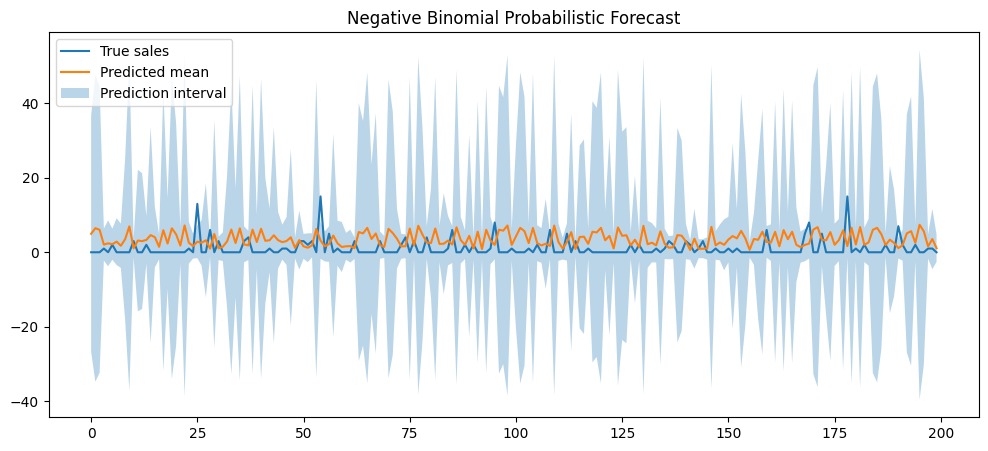

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt


model = ProbLSTM(
    input_size=len(features),
    hidden_size=128
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


epochs = 50

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for batch_x, batch_y in train_loader:

        mu, alpha = model(batch_x)

        loss = nll_loss(mu, alpha, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            mu, alpha = model(batch_x)

            loss = nll_loss(mu, alpha, batch_y)

            val_loss += loss.item()

    print(
        f"Epoch {epoch+1} | Train Loss {train_loss:.3f} | Val Loss {val_loss:.3f}"
    )


# Predictions
model.eval()

pred_mu = []
pred_sigma = []
true_vals = []

with torch.no_grad():

    for batch_x, batch_y in val_loader:

        mu, alpha = model(batch_x)

        variance = mu + alpha * mu**2
        sigma = torch.sqrt(variance)

        pred_mu.append(mu.numpy())
        pred_sigma.append(sigma.numpy())
        true_vals.append(batch_y.numpy())


mu = np.concatenate(pred_mu)
sigma = np.concatenate(pred_sigma)
true = np.concatenate(true_vals)

upper = mu + 2*sigma
lower = mu - 2*sigma

mae = np.mean(np.abs(mu - true))
rmse = np.sqrt(np.mean((mu - true)**2))
coverage = np.mean((true >= lower) & (true <= upper))

print("MAE:", mae)
print("RMSE:", rmse)
print("Coverage:", coverage)

plt.figure(figsize=(12,5))

plt.plot(true[:200], label="True sales")
plt.plot(mu[:200], label="Predicted mean")

plt.fill_between(
    range(200),
    lower[:200],
    upper[:200],
    alpha=0.3,
    label="Prediction interval"
)

plt.legend()
plt.title("Negative Binomial Probabilistic Forecast")
plt.show()